# 6CS012 - Worksheet 2
## Image Classification Using Softmax Regression
**Prepared by: Siman Giri**

---
## Section 3.1 — Decision Function
### Softmax Function

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [41]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
        z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
                           - m is the number of samples.
                           - n is the number of classes.
    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n), where
                       each row sums to 1.
    Notes:
        Uses numerical stabilization by subtracting the max value per row.
    """
    # Subtract max for numerical stability (prevents overflow in exp)
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [42]:
# ── Softmax Test ──────────────────────────────────────────────────────────────
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


### Prediction Function

In [43]:
def predict_softmax(X, W, b):
    """
    Predict class labels for a set of samples using the trained softmax model.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).
    Returns:
        numpy.ndarray: Predicted class labels of shape (n,).
    """
    z = np.dot(X, W) + b          # Compute logits  (n, c)
    probs = softmax(z)             # Convert to probabilities
    predicted_classes = np.argmax(probs, axis=1)  # Pick class with highest prob
    return predicted_classes

In [44]:
# ── Prediction Test ───────────────────────────────────────────────────────────
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


---
## Section 3.2 — Loss and Cost Functions

In [45]:
def loss_softmax(y_pred, y):
    """
    Compute the categorical cross-entropy loss.

    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities. Shape (n, c) or (c,).
        y      (numpy.ndarray): True one-hot labels.    Shape (n, c) or (c,).
    Returns:
        float: Average cross-entropy loss.
    """
    # Clip predictions to avoid log(0)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    # Element-wise: y * log(y_pred), then sum over classes, average over samples
    loss = -np.mean(np.sum(y * np.log(y_pred_clipped), axis=-1))
    return loss

In [46]:
# ── Loss Test ─────────────────────────────────────────────────────────────────
y_true_correct   = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct   = np.array([[0.9, 0.05, 0.05],
                              [0.1, 0.85, 0.05],
                              [0.05, 0.1,  0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                              [0.1,  0.05, 0.85],
                              [0.85, 0.1,  0.05]])

loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, "
    f"but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
)
print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


In [47]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy) over all samples.

    Parameters:
        X (numpy.ndarray): Feature matrix  (n, d).
        y (numpy.ndarray): One-hot labels  (n, c).
        W (numpy.ndarray): Weight matrix   (d, c).
        b (numpy.ndarray): Bias vector     (c,).
    Returns:
        float: Average cross-entropy loss.
    """
    n = X.shape[0]
    z = np.dot(X, W) + b        # Logits  (n, c)
    y_pred = softmax(z)          # Probabilities (n, c)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    total_loss = -np.sum(y * np.log(y_pred_clipped))
    return total_loss / n

In [48]:
# ── Cost Test ─────────────────────────────────────────────────────────────────
X_correct   = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct   = np.array([[1, 0],     [0, 1]])
W_correct   = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct   = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0],     [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)
print("Cost for correct prediction:  ", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction:   0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


---
## Section 3.3 — Gradient Descent

In [49]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function w.r.t. weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix  (n, d).
        y (numpy.ndarray): One-hot labels  (n, c).
        W (numpy.ndarray): Weight matrix   (d, c).
        b (numpy.ndarray): Bias vector     (c,).
    Returns:
        tuple: (grad_W of shape (d,c), grad_b of shape (c,))
    """
    n = X.shape[0]
    z = np.dot(X, W) + b          # Logits       (n, c)
    y_pred = softmax(z)            # Probabilities (n, c)
    diff = y_pred - y              # Residuals    (n, c)

    grad_W = np.dot(X.T, diff) / n  # (d, c)  — gradient w.r.t. W
    grad_b = np.sum(diff, axis=0) / n  # (c,)  — gradient w.r.t. b
    return grad_W, grad_b

In [50]:
# ── Gradient Test ─────────────────────────────────────────────────────────────
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Manual reference
z_test_manual   = np.dot(X_test, W_test) + b_test
y_pred_manual   = softmax(z_test_manual)
grad_W_manual   = np.dot(X_test.T, (y_pred_manual - y_test)) / X_test.shape[0]
grad_b_manual   = np.sum(y_pred_manual - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: Gradients w.r.t. W differ.\nExpected: {grad_W_manual}\nGot: {grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b differ.\nExpected: {grad_b_manual}\nGot: {grad_b}"
)
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [51]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimise weights and biases.

    Parameters:
        X         : Feature matrix (n, d).
        y         : One-hot labels (n, c).
        W         : Initial weight matrix (d, c).
        b         : Initial bias vector (c,).
        alpha     : Learning rate.
        n_iter    : Number of iterations.
        show_cost : Print cost every 100 iterations if True.
    Returns:
        tuple: (W_optimised, b_optimised, cost_history)
    """
    cost_history = []

    for i in range(n_iter):
        # 1. Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # 2. Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # 3. Record cost
        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        # 4. Optionally print progress
        if show_cost and i % 100 == 0:
            print(f"Iteration {i:4d} | Cost: {current_cost:.6f}")

    return W, b, cost_history

---
## Section 3.4 — Preparing the Dataset

### Question 1
> **Is extracting pixel values sufficient for effective feature extraction? Why or why not?**

**Answer:** Extracting raw pixel values is a reasonable starting point but is generally *not sufficient* for highly effective feature extraction. Raw pixel values capture all intensity information but carry no structural or semantic meaning — they are sensitive to shifts, rotations, and lighting changes. More advanced techniques such as edge detection, histogram of gradients (HoG), or learned embeddings (from CNNs) capture spatial relationships and invariances that raw pixels miss. However, for a simple baseline model like Softmax Regression on MNIST, normalised pixel values do work acceptably because the digits are pre-centred and size-normalised.

In [52]:
def plot_sample_images(X, y):
    """
    Plot one sample image for each digit class (0-9).

    Arguments:
        X (np.ndarray): Feature matrix containing pixel values.
        y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [53]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Read the MNIST CSV file, split into train/test sets, and plot one image per class.

    Arguments:
        csv_file     (str)   : Path to the CSV file containing MNIST data.
        test_size    (float) : Proportion for the test set (default 0.2).
        random_state (int)   : Random seed for reproducibility (default 42).
    Returns:
        X_train, X_test, y_train, y_test
    """
    # Load dataset
    df = pd.read_csv("/content/mnist_dataset.csv")

    # Separate labels and pixel features
    y = df.iloc[:, 0].values   # First column = label
    X = df.iloc[:, 1:].values  # Remaining columns = pixel values

    # Normalise pixel values to [0, 1]
    X = X / 255.0

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Visualise one sample per class
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

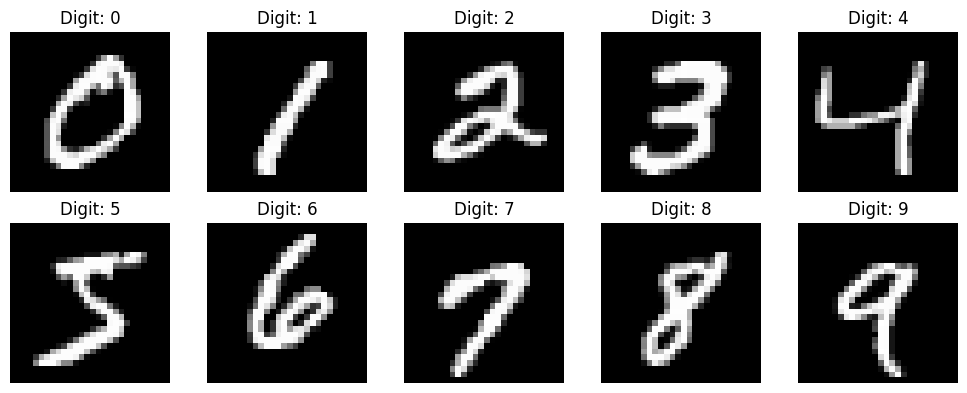

In [54]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Update the path below to wherever your MNIST CSV file is located.
CSV_PATH = "/content/mnist_dataset.csv"   # <-- change this to your actual file path

X_train, X_test, y_train, y_test = load_and_prepare_mnist(CSV_PATH)

---
## Section 3.5 — Training the Model

In [55]:
# Shape check before training
assert len(X_train) == len(y_train), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

Move forward: Dimension of Feature Matrix X and label vector y matched.


In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Iteration    0 | Cost: nan
Iteration  100 | Cost: nan
Iteration  200 | Cost: nan
Iteration  300 | Cost: nan
Iteration  400 | Cost: nan
Iteration  500 | Cost: nan
Iteration  600 | Cost: nan
Iteration  700 | Cost: nan
Iteration  800 | Cost: nan
Iteration  900 | Cost: nan


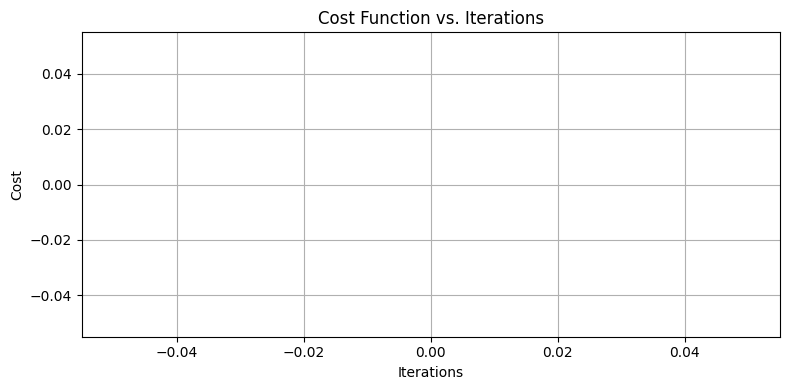

In [35]:
# One-hot encode labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]   # Number of features  (784 for MNIST)
c = y_train.shape[1]   # Number of classes   (10 for MNIST)

# Initialise parameters
np.random.seed(42)
W = np.random.randn(d, c) * 0.01  # Small random weights
b = np.zeros(c)                    # Zero biases

# Hyperparameters
alpha  = 0.1    # Learning rate
n_iter = 1000   # Iterations

# Train
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot cost vs iterations
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color='steelblue')
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Section 3.6 — Evaluating Model Performance

In [36]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix,
    precision, recall, and F1-score.

    Parameters:
        y_true (numpy.ndarray): True labels.
        y_pred (numpy.ndarray): Predicted labels.
    Returns:
        tuple: (confusion_matrix, precision, recall, f1)
    """
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

In [37]:
# Predict on test set
y_pred_test   = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)   # Convert one-hot back to integers

# Evaluate
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")


Confusion Matrix:
[[704   0   0   0   0   0   0   0   0   0]
 [784   0   0   0   0   0   0   0   0   0]
 [663   0   0   0   0   0   0   0   0   0]
 [685   0   0   0   0   0   0   0   0   0]
 [663   0   0   0   0   0   0   0   0   0]
 [617   0   0   0   0   0   0   0   0   0]
 [693   0   0   0   0   0   0   0   0   0]
 [720   0   0   0   0   0   0   0   0   0]
 [644   0   0   0   0   0   0   0   0   0]
 [711   0   0   0   0   0   0   0   0   0]]
Precision : 0.01
Recall    : 0.10
F1-Score  : 0.02


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


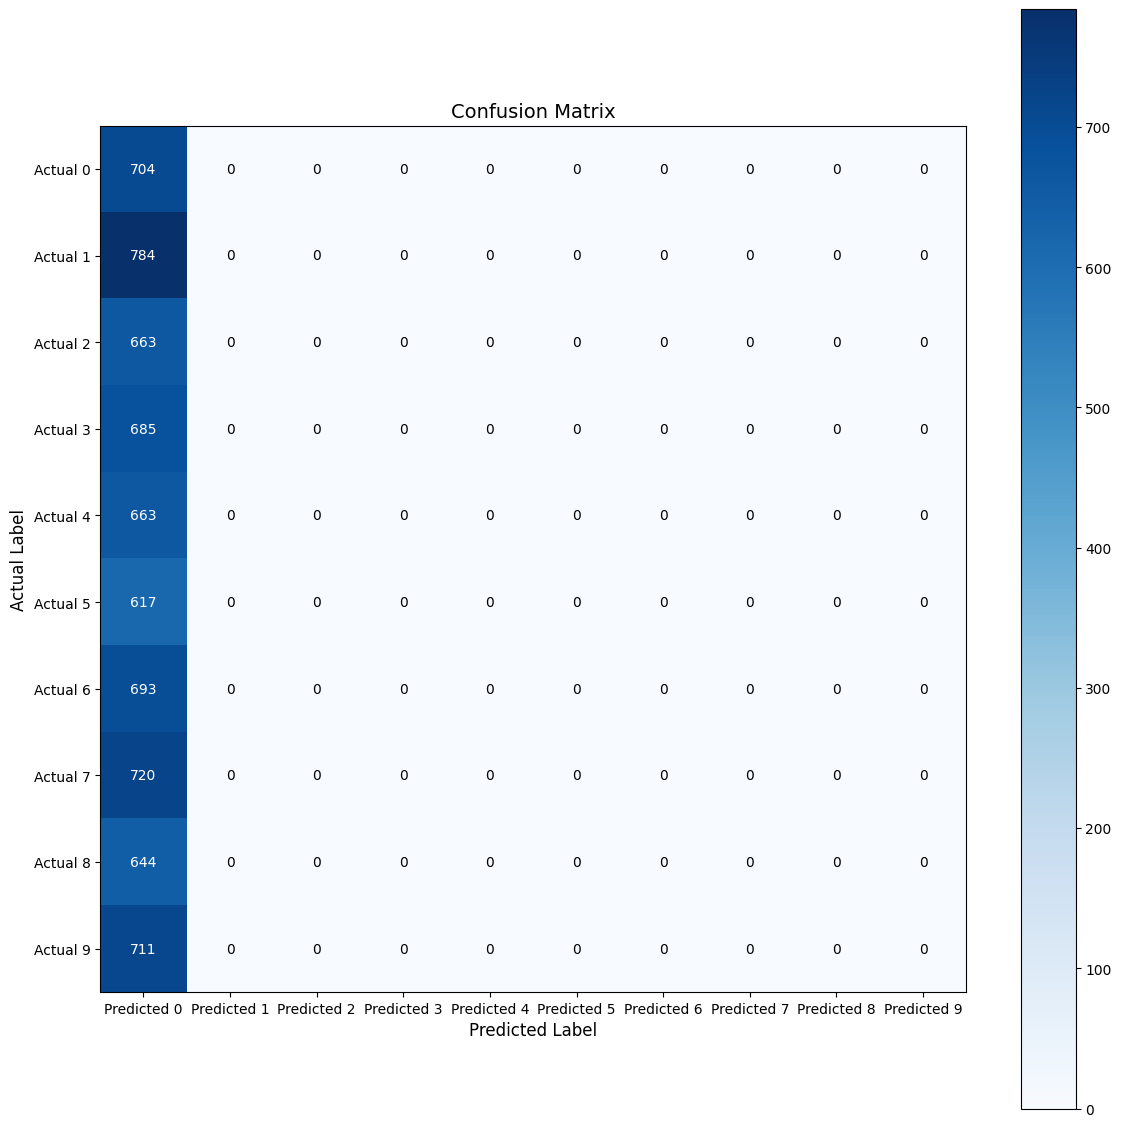

In [38]:
# Visualise Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}'    for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center', va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black'
        )

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label',    fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

---
## Section 4 — Linear Separability and Logistic Regression

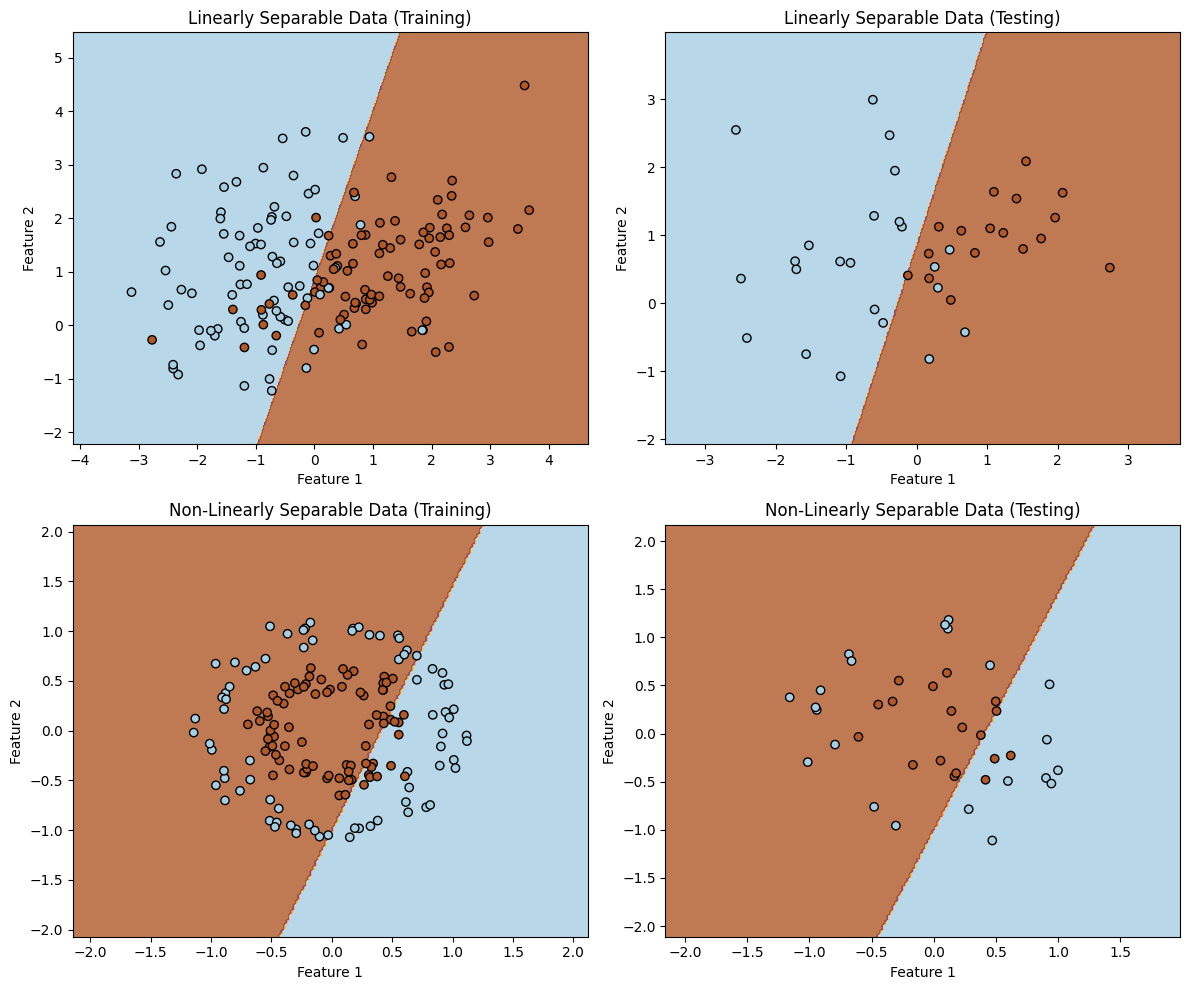

In [39]:
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# ── Linearly separable dataset ────────────────────────────────────────────────
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# ── Non-linearly separable dataset (circles) ──────────────────────────────────
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# ── Decision boundary helper ──────────────────────────────────────────────────
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# ── Plot all four panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(axes[0, 0], logistic_model_linear_separable,
                       X_train_linear, y_train_linear,
                       'Linearly Separable Data (Training)')
plot_decision_boundary(axes[0, 1], logistic_model_linear_separable,
                       X_test_linear, y_test_linear,
                       'Linearly Separable Data (Testing)')
plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable,
                       X_train_non_linear, y_train_non_linear,
                       'Non-Linearly Separable Data (Training)')
plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable,
                       X_test_non_linear, y_test_non_linear,
                       'Non-Linearly Separable Data (Testing)')

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

### Question 2 — Interpretation of the Output

**Linearly separable data (top row):** The logistic regression model produces a clean straight-line decision boundary that effectively separates the two classes in both the training and testing panels. The model generalises well, with similar boundaries on both sets, indicating no overfitting.

**Non-linearly separable data (bottom row):** The dataset forms two concentric circles, which cannot be separated by a straight line. Logistic regression still draws a linear boundary, so a large number of points near the boundary are misclassified. Both training and testing panels show the same poor boundary, confirming this is a fundamental model-capacity limitation, not overfitting — logistic regression simply lacks the expressiveness needed for this geometry.

**Key takeaway:** Logistic regression is suitable only when classes are (approximately) linearly separable. For circular or other non-linear distributions, non-linear models such as kernel SVMs, decision trees, or neural networks are required.

---

### Question 3 — Challenges Faced

1. **Numerical stability in softmax:** Computing `exp(z)` directly can overflow for large logits. This was resolved by subtracting the row-wise maximum before exponentiation (`z - max(z)`).
2. **Log of zero in cross-entropy:** When a predicted probability is exactly 0, `log(0)` is undefined. Clipping predictions with `np.clip(y_pred, 1e-15, 1-1e-15)` avoids this.
3. **One-hot encoding alignment:** The labels `y_train` must be one-hot encoded before computing gradients; forgetting this step causes shape mismatches in the matrix operations.
4. **Learning rate tuning:** A learning rate that is too large causes the cost to diverge; too small and convergence is very slow. `alpha = 0.1` with 1000 iterations was a reasonable balance for MNIST.
5. **Memory usage:** Training on the full 60,000-sample MNIST dataset with full-batch gradient descent is memory-intensive. Mini-batch GD would be a practical improvement for larger experiments.